## Data Loading

In [5]:
# import the libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [6]:
df = pd.read_csv("/content/corporate_income_statement (1).csv")

In [7]:
df.head(5)

,symbol,fiscalDateEnding,reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,...,depreciation,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,interestAndDebtExpense,netIncomeFromContinuingOperations,comprehensiveIncomeNetOfTax,ebit,ebitda,netIncome
0,NVDA,2025-10-31,USD,4.184900e+10,5.700600e+10,1.515700e+10,1.515700e+10,3.601000e+10,1.134000e+09,4.705000e+09,...,NaN,751000000.0,3.793600e+10,6.026000e+09,NaN,3.191000e+10,NaN,3.799700e+10,3.874800e+10,3.191000e+10
1,NVDA,2025-07-31,USD,3.385300e+10,4.674300e+10,1.289000e+10,1.289000e+10,2.844000e+10,1.122000e+09,4.291000e+09,...,NaN,669000000.0,3.120600e+10,4.784000e+09,NaN,2.642200e+10,NaN,3.126800e+10,3.193700e+10,2.642200e+10
2,NVDA,2025-04-30,USD,2.666800e+10,4.406200e+10,1.739400e+10,1.739400e+10,2.163800e+10,1.041000e+09,3.989000e+09,...,NaN,611000000.0,2.191000e+10,3.135000e+09,NaN,1.877500e+10,NaN,2.197300e+10,2.258400e+10,1.877500e+10
3,NVDA,2025-01-31,USD,2.872300e+10,3.933100e+10,1.060800e+10,1.060800e+10,2.403400e+10,9.750000e+08,3.714000e+09,...,NaN,543000000.0,2.521700e+10,3.126000e+09,NaN,2.209100e+10,NaN,2.527800e+10,2.582100e+10,2.209100e+10
4,NVDA,2024-10-31,USD,2.615600e+10,3.508200e+10,8.926000e+09,8.926000e+09,2.186900e+10,8.970000e+08,3.390000e+09,...,NaN,478000000.0,2.231600e+10,3.007000e+09,NaN,1.930900e+10,NaN,2.237700e+10,2.285500e+10,1.930900e+10


In [8]:
df.tail(3)

,symbol,fiscalDateEnding,reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,...,depreciation,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,interestAndDebtExpense,netIncomeFromContinuingOperations,comprehensiveIncomeNetOfTax,ebit,ebitda,netIncome
1747,PLTR,2019-09-30,USD,125468000.0,190541000.0,65073000.0,65073000.0,-144140000.0,74062000.0,75880000.0,...,NaN,3061000.0,-137834000.0,2026000.0,NaN,-139860000.0,NaN,-137661000.0,-134600000.0,-139860000.0
1748,PLTR,2019-06-30,NaN,119731000.0,176320000.0,56589000.0,56589000.0,-140115000.0,70589000.0,78724000.0,...,NaN,3194500.0,-132677000.0,1389000.0,NaN,NaN,NaN,-140115000.0,-136920500.0,-134066000.0
1749,PLTR,2019-03-31,NaN,110629000.0,161328000.0,50699000.0,50699000.0,-142426500.0,67337000.0,76924000.0,...,NaN,3194500.0,-137000000.0,3229500.0,NaN,NaN,NaN,-142426500.0,-139232000.0,-140229500.0


## Initial Data Exploration

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1750 entries, 0 to 1749
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   symbol                             1750 non-null   object 
 1   fiscalDateEnding                   1750 non-null   object 
 2   reportedCurrency                   1748 non-null   object 
 3   grossProfit                        1746 non-null   float64
 4   totalRevenue                       1750 non-null   float64
 5   costOfRevenue                      1749 non-null   float64
 6   costofGoodsAndServicesSold         1749 non-null   float64
 7   operatingIncome                    1746 non-null   float64
 8   sellingGeneralAndAdministrative    1686 non-null   float64
 9   researchAndDevelopment             1430 non-null   float64
 10  operatingExpenses                  1746 non-null   float64
 11  investmentIncomeNet                0 non-null      float

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
grossProfit,1746.0,2.036128e+10,4.343054e+10,-4.844500e+10,2.537714e+09,7.945500e+09,2.305425e+10,5.885430e+11
totalRevenue,1750.0,4.405264e+10,8.107181e+10,1.825000e+04,5.128575e+09,1.784850e+10,5.189425e+10,9.899180e+11
costOfRevenue,1749.0,2.410546e+10,4.233846e+10,-1.281730e+11,1.239000e+09,5.751000e+09,3.023300e+10,4.013750e+11
costofGoodsAndServicesSold,1749.0,2.410546e+10,4.233846e+10,-1.281730e+11,1.239000e+09,5.751000e+09,3.023300e+10,4.013750e+11
operatingIncome,1746.0,1.052531e+10,3.411198e+10,-4.236000e+10,9.207500e+08,3.398000e+09,7.248500e+09,5.006850e+11
sellingGeneralAndAdministrative,1686.0,3.709655e+09,6.183070e+09,2.700000e+06,3.348838e+08,1.453550e+09,4.274495e+09,4.517100e+10
researchAndDevelopment,1430.0,3.056359e+09,6.660010e+09,0.000000e+00,6.200000e+07,8.285000e+08,2.656500e+09,6.374300e+10
operatingExpenses,1746.0,1.492444e+10,3.216817e+10,-1.902200e+10,1.301000e+09,4.671000e+09,1.420975e+10,3.186680e+11
investmentIncomeNet,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
netInterestIncome,598.0,1.289887e+09,6.321937e+09,-4.384000e+10,-3.230000e+08,-7.615000e+07,1.792500e+08,6.198800e+10


In [11]:
df.shape

(1750, 27)

In [12]:
len(df)

1750

In [13]:
df['symbol'].unique()

array(['NVDA', 'MSFT', 'AAPL', 'GOOG', 'AMZN', 'META', 'AVGO', 'TSM',
       'TSLA', 'BRK-B', 'JPM', 'ORCL', 'WMT', 'LLY', 'V', 'MA', 'NFLX',
       'XOM', 'JNJ', 'COST', 'HD', 'BABA', 'PLTR'], dtype=object)

## Selecting Tech Companies

In [14]:
# select tech companies

tech_companies = ['NVDA', 'MSFT', 'AAPL', 'GOOG', 'AMZN', 'META', 'AVGO', 'TSM','ORCL','NFLX','PLTR']

In [15]:
df = df[df['symbol'].isin(tech_companies)]

In [16]:
df['symbol'].unique()

array(['NVDA', 'MSFT', 'AAPL', 'GOOG', 'AMZN', 'META', 'AVGO', 'TSM',
       'ORCL', 'NFLX', 'PLTR'], dtype=object)

In [17]:
df.shape

(813, 27)

## Data Cleaning

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 813 entries, 0 to 1749
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   symbol                             813 non-null    object 
 1   fiscalDateEnding                   813 non-null    object 
 2   reportedCurrency                   811 non-null    object 
 3   grossProfit                        809 non-null    float64
 4   totalRevenue                       813 non-null    float64
 5   costOfRevenue                      813 non-null    float64
 6   costofGoodsAndServicesSold         813 non-null    float64
 7   operatingIncome                    809 non-null    float64
 8   sellingGeneralAndAdministrative    813 non-null    float64
 9   researchAndDevelopment             813 non-null    float64
 10  operatingExpenses                  809 non-null    float64
 11  investmentIncomeNet                0 non-null      float64
 12

In [19]:
# Convert fiscalDatEnding to datetime type

df['fiscalDateEnding'] = pd.to_datetime(df['fiscalDateEnding'])
df = df.sort_values(['symbol','fiscalDateEnding'])

In [20]:
# check for duplicates

dupes = df.duplicated().sum()
print(f"Found {dupes} duplicate rows")

Found 0 duplicate rows


In [21]:
# Check null values

df.isnull().sum()

,0
symbol,0
fiscalDateEnding,0
reportedCurrency,2
grossProfit,4
totalRevenue,0
costOfRevenue,0
costofGoodsAndServicesSold,0
operatingIncome,4
sellingGeneralAndAdministrative,0
researchAndDevelopment,0


In [22]:
# Drop columns which are 100% empty

empty_cols = ['investmentIncomeNet','nonInterestIncome',  'depreciation',
              'interestAndDebtExpense', 'comprehensiveIncomeNetOfTax' ]

df = df.drop(columns = empty_cols, errors='ignore')

In [23]:
df.shape

(813, 22)

In [24]:
# Replace non-bank interest income by 0

df['netInterestIncome'] = df['netInterestIncome'].fillna(0)
df['interestIncome'] = df['interestIncome'].fillna(0)
df['otherNonOperatingIncome'] = df['otherNonOperatingIncome'].fillna(0)

In [25]:
# Drop these columns with less NA values

df = df.dropna(subset=['grossProfit','operatingIncome','netIncome','ebit'])

In [26]:
df[df['reportedCurrency'].isnull()]

,symbol,fiscalDateEnding,reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,...,interestIncome,interestExpense,otherNonOperatingIncome,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,ebit,ebitda,netIncome
1749,PLTR,2019-03-31,NaN,110629000.0,161328000.0,50699000.0,50699000.0,-142426500.0,67337000.0,76924000.0,...,0.0,NaN,0.0,3194500.0,-137000000.0,3229500.0,NaN,-142426500.0,-139232000.0,-140229500.0
1748,PLTR,2019-06-30,NaN,119731000.0,176320000.0,56589000.0,56589000.0,-140115000.0,70589000.0,78724000.0,...,0.0,NaN,0.0,3194500.0,-132677000.0,1389000.0,NaN,-140115000.0,-136920500.0,-134066000.0


In [27]:
df[df['symbol'] == 'PLTR']

,symbol,fiscalDateEnding,reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,...,interestIncome,interestExpense,otherNonOperatingIncome,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,ebit,ebitda,netIncome
1749,PLTR,2019-03-31,NaN,110629000.0,1.613280e+08,50699000.0,50699000.0,-142426500.0,67337000.0,76924000.0,...,0.0,NaN,0.0,3194500.0,-137000000.0,3229500.0,NaN,-142426500.0,-139232000.0,-140229500.0
1748,PLTR,2019-06-30,NaN,119731000.0,1.763200e+08,56589000.0,56589000.0,-140115000.0,70589000.0,78724000.0,...,0.0,NaN,0.0,3194500.0,-132677000.0,1389000.0,NaN,-140115000.0,-136920500.0,-134066000.0
1747,PLTR,2019-09-30,USD,125468000.0,1.905410e+08,65073000.0,65073000.0,-144140000.0,74062000.0,75880000.0,...,3390000.0,173000.0,0.0,3061000.0,-137834000.0,2026000.0,-139860000.0,-137661000.0,-134600000.0,-139860000.0
1746,PLTR,2019-12-31,USD,153456000.0,2.293580e+08,75902000.0,75902000.0,-147451000.0,112207000.0,75835000.0,...,2137000.0,2666000.0,0.0,2805000.0,-155437000.0,3890000.0,-159327000.0,-152771000.0,-149966000.0,-159327000.0
1745,PLTR,2020-03-31,USD,165033000.0,2.293270e+08,64294000.0,64294000.0,-70185000.0,70765000.0,65800000.0,...,3267000.0,4594000.0,0.0,3671000.0,-51717000.0,2557000.0,-54274000.0,-47123000.0,-43452000.0,-54274000.0
1744,PLTR,2020-06-30,USD,183479000.0,2.518890e+08,68410000.0,68410000.0,-99145000.0,93291000.0,86815000.0,...,551000.0,5646000.0,0.0,4122000.0,-109512000.0,943000.0,-110455000.0,-103866000.0,-99744000.0,-110455000.0
1743,PLTR,2020-09-30,USD,140026000.0,2.893660e+08,149340000.0,149340000.0,-847777000.0,338977000.0,313915000.0,...,494000.0,2085000.0,0.0,2515000.0,-861862000.0,-8543000.0,-853319000.0,-859777000.0,-857262000.0,-853319000.0
1742,PLTR,2020-12-31,USD,251588000.0,3.220910e+08,70503000.0,70503000.0,-156572000.0,166411000.0,94130000.0,...,368000.0,1814000.0,0.0,3563000.0,-155936000.0,-7593000.0,-148343000.0,-154122000.0,-150559000.0,-148343000.0
1741,PLTR,2021-03-31,USD,267123000.0,3.412340e+08,74111000.0,74111000.0,-114014000.0,146569000.0,98471000.0,...,376000.0,1840000.0,-4518000.0,3237000.0,-120372000.0,3102000.0,-123474000.0,-118532000.0,-115295000.0,-123474000.0
1740,PLTR,2021-06-30,USD,284716000.0,3.756420e+08,90926000.0,90926000.0,-146148000.0,157961000.0,110524000.0,...,372000.0,590000.0,2497000.0,4762000.0,-144241000.0,-5661000.0,-138580000.0,-143651000.0,-138889000.0,-138580000.0


In [28]:
# impute nulls in reportedCurrency with USD
df['reportedCurrency'] = df['reportedCurrency'].fillna('USD')

## Feature Engineering

In [29]:
# Growth Metrics
df['revenue_growth'] = df.groupby('symbol')['totalRevenue'].pct_change(4)
df['net_income_growth'] = df.groupby('symbol')['netIncome'].pct_change(4)

In [30]:
df.shape

(809, 24)

## Detecting & Removing Outliers

In [31]:
# Use IQR method to detect outliers

def find_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
  return outliers



In [32]:
growth_outliers = find_outliers_iqr(df, 'revenue_growth')

In [33]:
growth_outliers.shape

(36, 24)

In [34]:
# Remove outliers

df = df.drop(growth_outliers.index)

In [35]:
df.shape

(773, 24)

## Data Analysis

### Q1. Which companies are growing their profits faster than their sales? (Net income growth vs revenue growth). Find the Growth Quality Score (Operating Efficiency)

In [36]:
# Growth analysis

growth_summary = df.groupby('symbol').agg({
    'revenue_growth': 'mean',
    'net_income_growth': 'mean'
}).reset_index()

growth_summary['growth_quality'] = (growth_summary['net_income_growth'] - growth_summary['revenue_growth'])

growth_summary.sort_values('growth_quality', ascending=False)

,symbol,revenue_growth,net_income_growth,growth_quality
2,AVGO,0.153539,1.473354,1.319815
1,AMZN,0.257078,1.236719,0.979641
6,NFLX,0.233859,1.067110,0.833250
9,PLTR,0.335712,0.733947,0.398235
7,NVDA,0.215938,0.421288,0.205350
0,AAPL,0.153449,0.232451,0.079003
10,TSM,0.168744,0.234074,0.065330
3,GOOG,0.224486,0.246024,0.021538
4,META,0.341664,0.292664,-0.049000
8,ORCL,0.083076,-0.012124,-0.095200


### Q2. Are companies becoming more or less profitable over time? How is profit margin changing over time?


In [37]:
# profitability features

df['operating_margin'] = df['operatingIncome'] / df['totalRevenue']
df['net_margin'] = df['netIncome'] / df['totalRevenue']

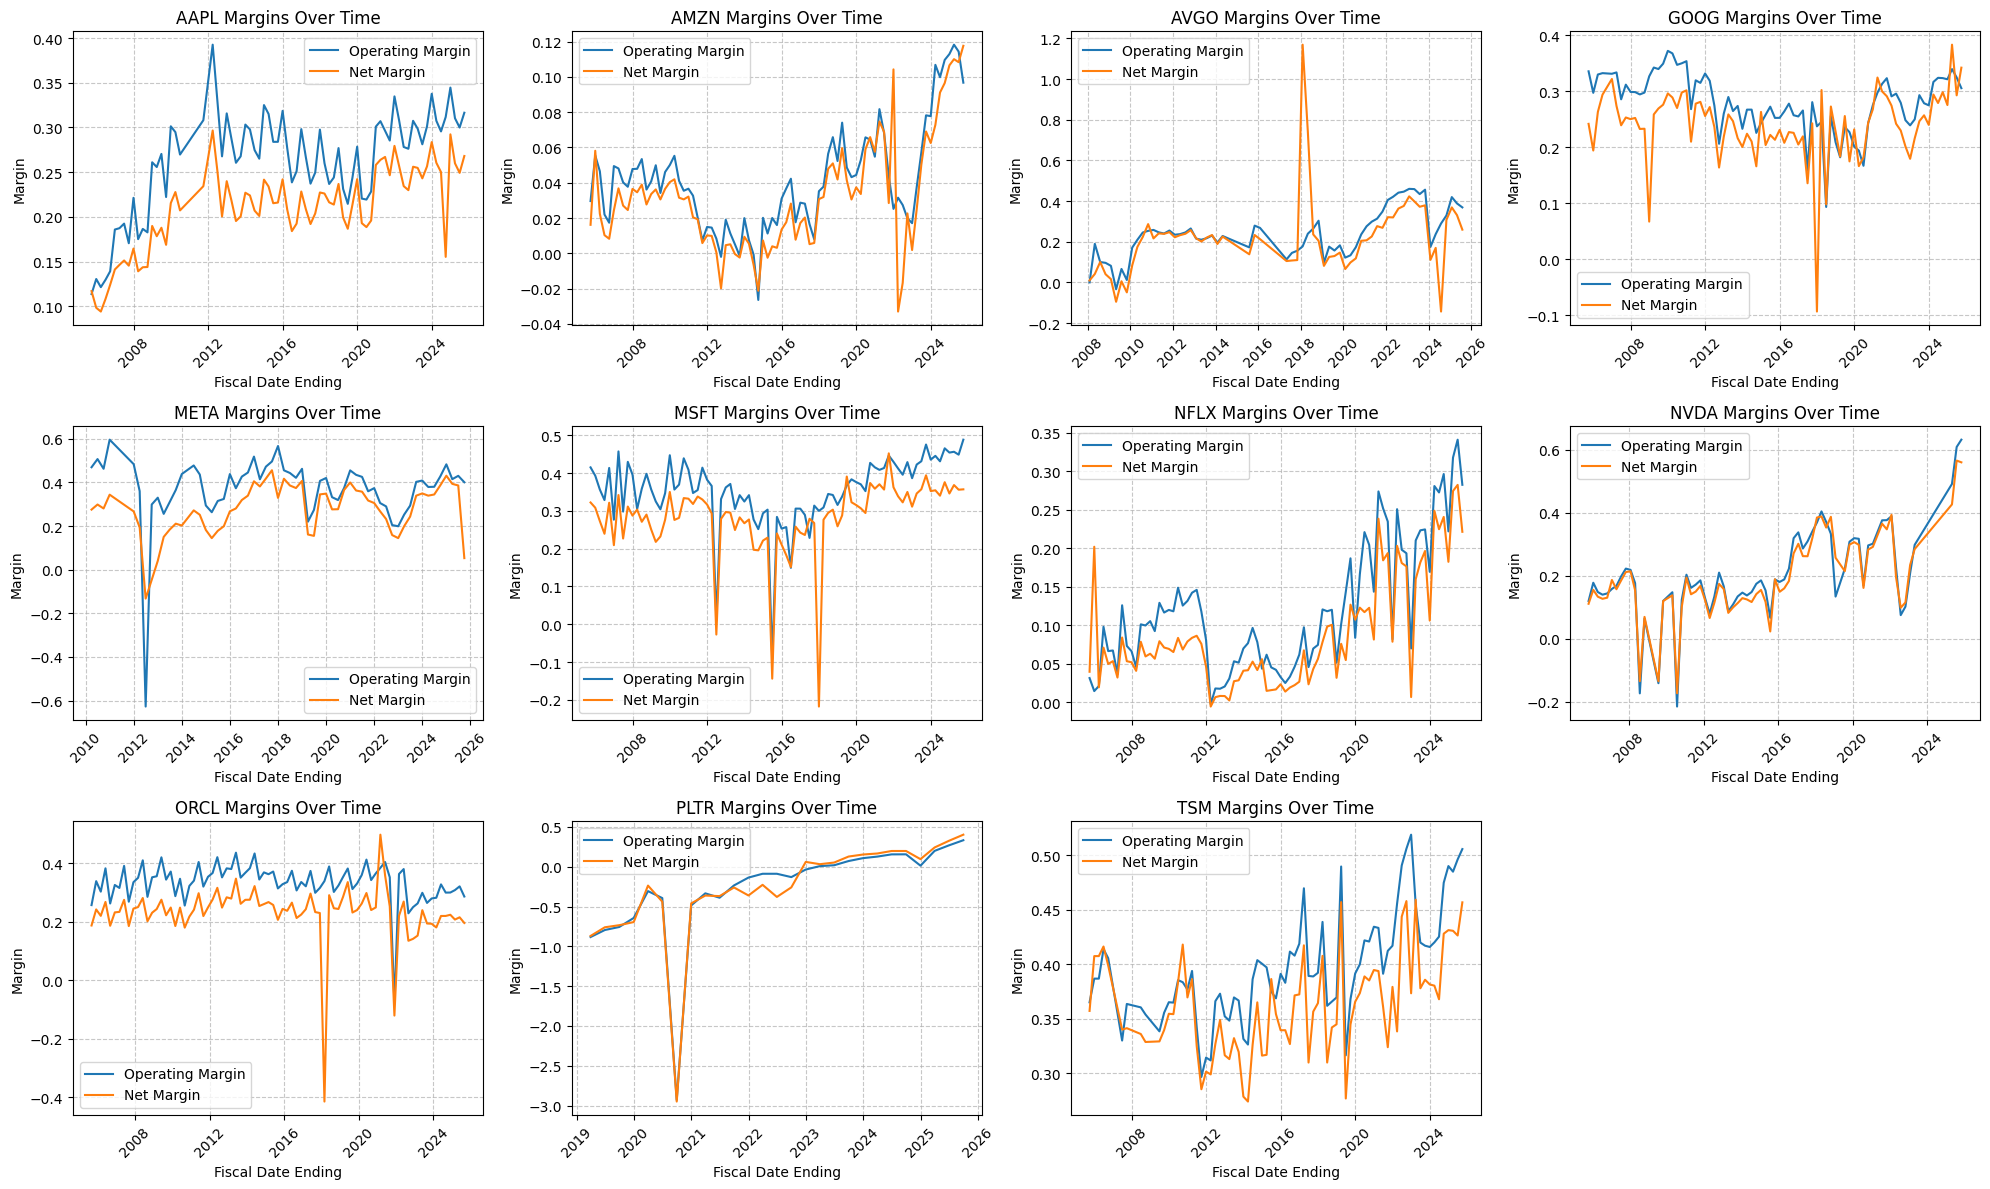

In [38]:
symbols = df['symbol'].unique()
num_symbols = len(symbols)

# Determine grid size for subplots
num_cols = 4  # You can adjust this for better visualization
num_rows = math.ceil(num_symbols / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4), squeeze=False) # squeeze=False ensures axes is always a 2D array
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, symbol in enumerate(symbols):
    ax = axes[i]
    company_df = df[df['symbol'] == symbol].sort_values('fiscalDateEnding')

    ax.plot(company_df['fiscalDateEnding'], company_df['operating_margin'], label='Operating Margin')
    ax.plot(company_df['fiscalDateEnding'], company_df['net_margin'], label='Net Margin')

    ax.set_title(f'{symbol} Margins Over Time')
    ax.set_xlabel('Fiscal Date Ending')
    ax.set_ylabel('Margin')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Q3. How are companies allocating their spending as they grow? (R&D Vs Sales & Administrative Cost)

In [39]:
# r&d and sga features

df['rd_ratio'] = df['researchAndDevelopment'] / df['totalRevenue']
df['sga_ratio'] = df['sellingGeneralAndAdministrative'] / df['totalRevenue']

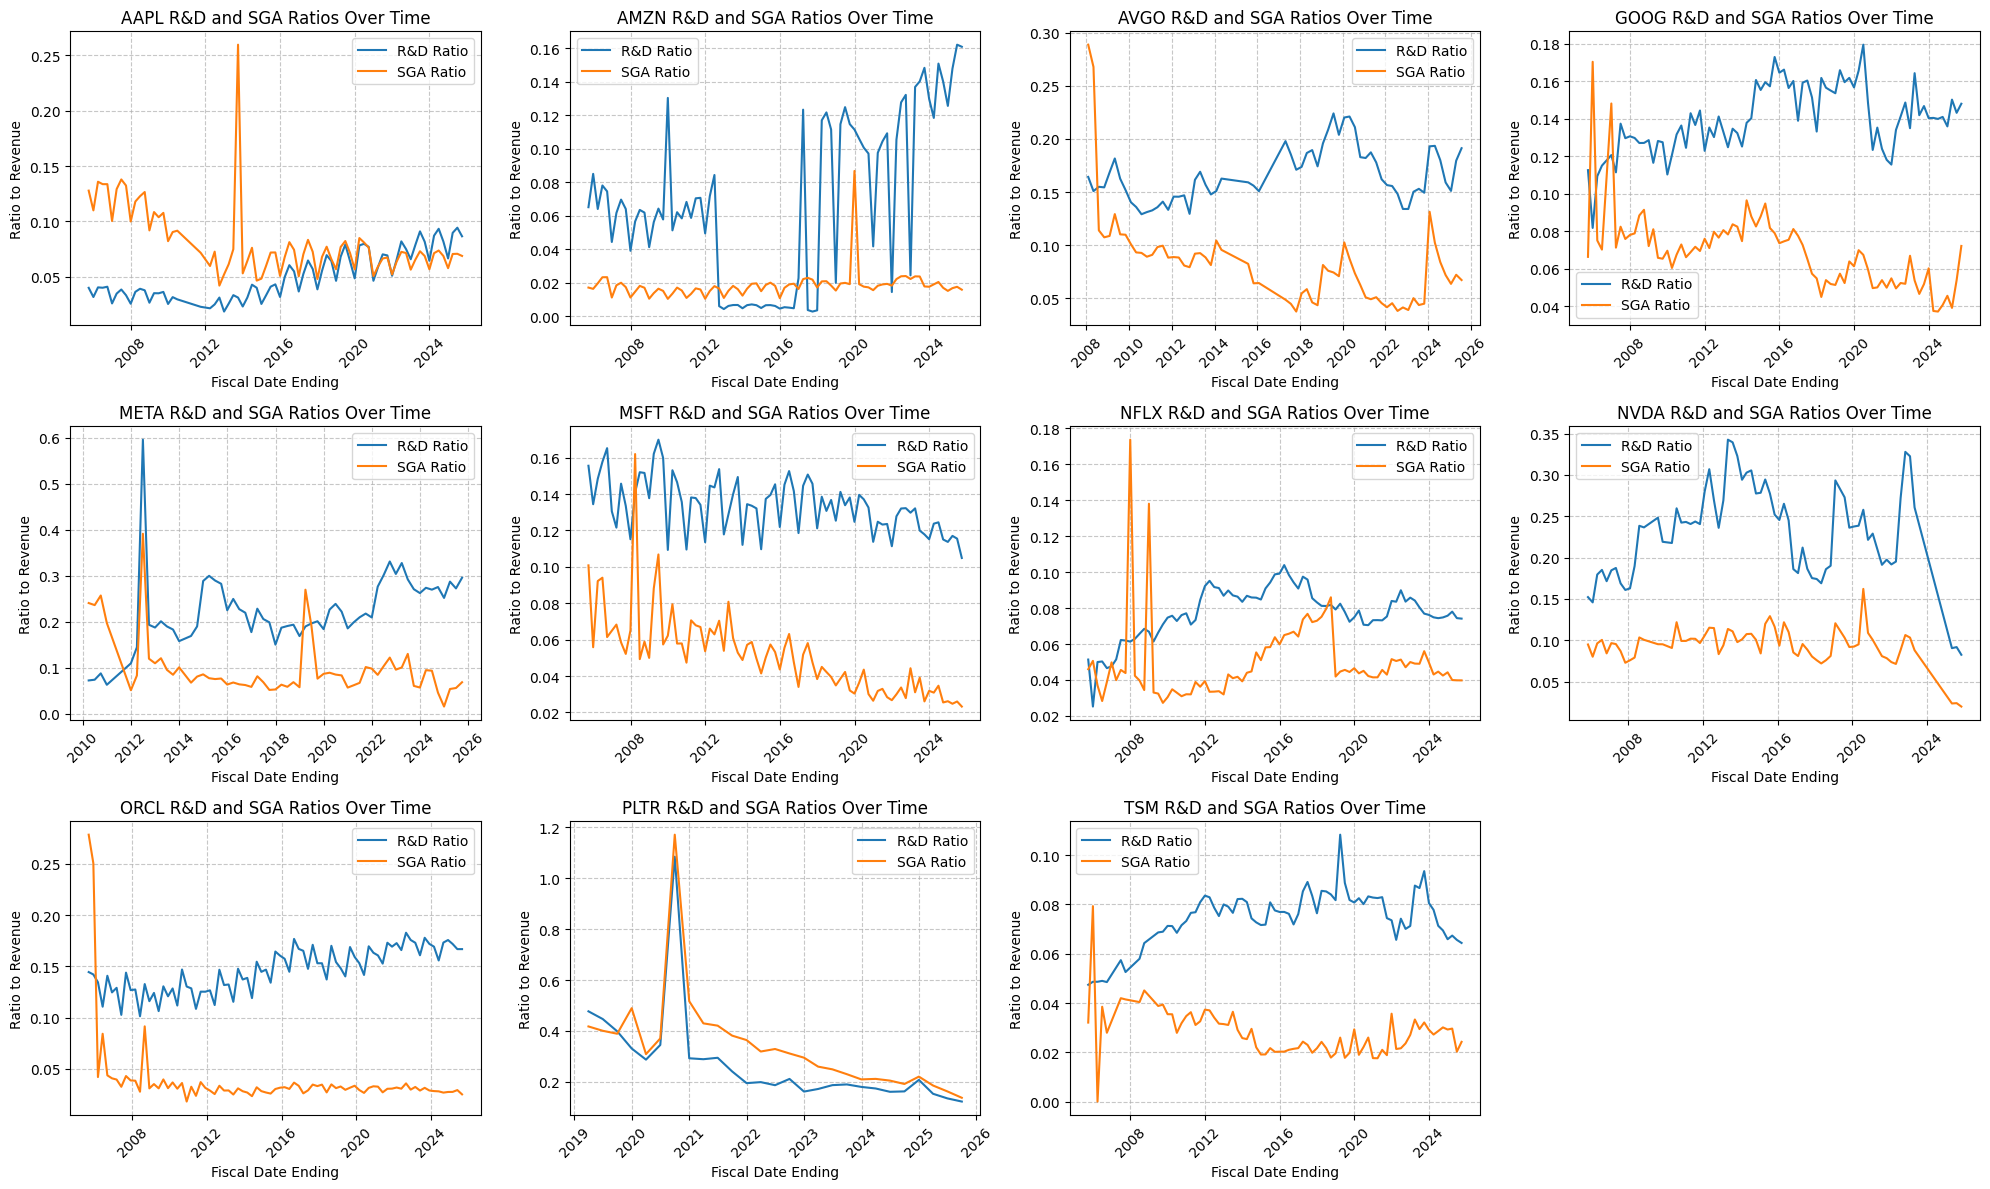

In [40]:
symbols = df['symbol'].unique()
num_symbols = len(symbols)

# Determine grid size for subplots
num_cols = 4  # You can adjust this for better visualization
num_rows = math.ceil(num_symbols / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4), squeeze=False) # squeeze=False ensures axes is always a 2D array
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, symbol in enumerate(symbols):
    ax = axes[i]
    company_df = df[df['symbol'] == symbol].sort_values('fiscalDateEnding')

    ax.plot(company_df['fiscalDateEnding'], company_df['rd_ratio'], label='R&D Ratio')
    ax.plot(company_df['fiscalDateEnding'], company_df['sga_ratio'], label='SGA Ratio')

    ax.set_title(f'{symbol} R&D and SGA Ratios Over Time')
    ax.set_xlabel('Fiscal Date Ending')
    ax.set_ylabel('Ratio to Revenue')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Q4. Which companies are reliable earners, and which are risky bets? Perform Stability & Risk Analysis (Volatility)

In [41]:
# Stability analysis

#risk summary
risk_summary = df.groupby('symbol').agg({
    'revenue_growth': 'std',
    'net_margin': 'std'
}).reset_index()

risk_summary.columns = ['symbol', 'revenue_volability', 'margin_volatility']

risk_summary.sort_values(by='margin_volatility')

,symbol,revenue_volability,margin_volatility
1,AMZN,0.114175,0.031753
10,TSM,0.172339,0.045232
0,AAPL,0.168917,0.046288
3,GOOG,0.142877,0.063048
6,NFLX,0.112870,0.072042
8,ORCL,0.118638,0.097588
5,MSFT,0.100433,0.099435
4,META,0.177380,0.118198
7,NVDA,0.262349,0.133424
2,AVGO,0.155417,0.184200


###  Q5. When we weigh how fast a company is growing against how profitable it actually is, which companies emerge as our top investment targets?


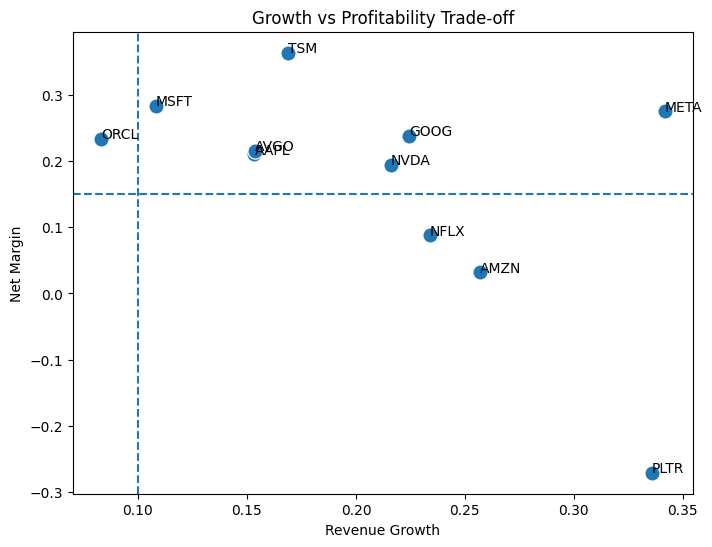

In [42]:
# Growth vs Profitability

summary = df.groupby('symbol').agg({
    'revenue_growth': 'mean',
    'net_margin': 'mean'
}).reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(data = summary, x = 'revenue_growth', y = 'net_margin', s=120)

for i in range(len(summary)):
  plt.text(summary['revenue_growth'][i],summary['net_margin'][i], summary['symbol'][i])

plt.axhline(0.15, linestyle='--')
plt.axvline(0.1, linestyle='--')

plt.title('Growth vs Profitability Trade-off')
plt.xlabel('Revenue Growth')
plt.ylabel('Net Margin')
plt.show()

In [43]:
# Classification

def classify(row):
  if row['revenue_growth'] > 0.1 and row['net_margin'] > 0.15:
    return "Top Picks"
  elif row['revenue_growth'] > 0.1:
    return "Risky Growth"
  elif row['net_margin'] > 0.15:
    return "Stable"
  else:
    return "At Risk"

summary['category'] = summary.apply(classify, axis = 1)
summary.sort_values(by='category')


,symbol,revenue_growth,net_margin,category
1,AMZN,0.257078,0.032035,Risky Growth
6,NFLX,0.233859,0.087952,Risky Growth
9,PLTR,0.335712,-0.270576,Risky Growth
8,ORCL,0.083076,0.233442,Stable
0,AAPL,0.153449,0.209980,Top Picks
2,AVGO,0.153539,0.215587,Top Picks
3,GOOG,0.224486,0.238336,Top Picks
4,META,0.341664,0.274778,Top Picks
5,MSFT,0.108123,0.283161,Top Picks
7,NVDA,0.215938,0.194372,Top Picks


# Project Report: Analysis of Tech Company Financial Performance

## 1. Executive Summary

This report presents a comprehensive financial analysis of a selection of leading technology companies, utilizing their corporate income statement data. The primary objective was to evaluate growth, profitability, spending allocation, stability, and overall investment potential. We've identified 'Top Picks' demonstrating balanced growth and profitability, alongside 'Risky Growth' and 'Stable' companies, and those categorized 'At Risk'. This analysis provides data-driven insights to inform strategic decisions for stakeholders.

## 2. Introduction & Objective

In today's dynamic technology landscape, understanding the financial health and strategic decisions of companies is crucial for investors and stakeholders. This project aims to delve into the corporate income statements of key tech players to answer critical business questions, including:

*   Which companies exhibit superior 'growth quality' by increasing profits faster than sales?
*   How are companies' profit margins evolving over time, indicating improving or declining profitability?
*   How do companies allocate their spending between R&D and Sales & Administrative costs as they grow?
*   Which companies are reliable earners with stable performance, and which represent riskier investment bets?
*   Considering both growth and profitability, which companies emerge as the most attractive investment targets?

## 3. Data Source and Preprocessing

The analysis was performed on a dataset containing corporate income statement information. The following steps were undertaken to prepare the data:

1.  **Data Loading**: Loaded `corporate_income_statement (1).csv` into a pandas DataFrame.
2.  **Company Selection**: Filtered the dataset to focus on 11 prominent tech companies: `NVDA`, `MSFT`, `AAPL`, `GOOG`, `AMZN`, `META`, `AVGO`, `TSM`, `ORCL`, `NFLX`, `PLTR`.
3.  **Data Type Conversion**: The `fiscalDateEnding` column was converted to datetime objects for time-series analysis.
4.  **Handling Missing Values & Irrelevant Columns**:
    *   Columns entirely composed of null values (`investmentIncomeNet`, `nonInterestIncome`, `depreciation`, `interestAndDebtExpense`, `comprehensiveIncomeNetOfTax`) were dropped.
    *   Null values in `netInterestIncome`, `interestIncome`, and `otherNonOperatingIncome` were imputed with `0`.
    *   Rows with missing values in crucial financial metrics (`grossProfit`, `operatingIncome`, `netIncome`, `ebit`) were removed.
    *   Missing `reportedCurrency` values were imputed with 'USD', specifically affecting initial PLTR entries.
5.  **Duplicate Check**: Verified and confirmed no duplicate rows were present.
6.  **Outlier Removal**: Outliers in `revenue_growth` (identified using the IQR method) were removed to ensure robust analysis.

## 4. Key Findings and Analysis

### Q1: Growth Quality Score (Net Income Growth vs. Revenue Growth)

To assess which companies are growing their profits more efficiently than their sales, a 'growth quality' score was calculated as the difference between net income growth and revenue growth (both measured as 4-period percentage change). A higher positive score indicates better operating efficiency.

**Top Performers by Growth Quality:**

1.  **AVGO (1.32)**
2.  **AMZN (0.98)**
3.  **NFLX (0.83)**
4.  **PLTR (0.40)**

This suggests that these companies have been particularly effective at translating revenue increases into even greater net income increases, potentially through improved cost management or operational leverage. In contrast, **MSFT (-0.22)** and **ORCL (-0.095)** showed negative growth quality, indicating net income growth lagging behind revenue growth.

### Q2: Profitability Trends (Operating Margin & Net Margin)

We analyzed the trends in operating margin and net margin over time for each company to understand their evolving profitability.

**Observations from Visualization:**

*   **General Trend**: Operating margin typically exceeds net margin due to interest and tax considerations.
*   **Volatility**: Companies like **PLTR** and **AVGO** showed significant volatility in net margins, with **PLTR** experiencing considerable negative margins in earlier periods, reflecting substantial investment phases or losses.
*   **Growth in Margins**: **NVDA**, **NFLX**, and **AMZN** demonstrated a general upward trend in both margins, indicating improving profitability.
*   **Stability**: Established players like **AAPL** and **MSFT** maintained relatively stable and healthy positive margins, though with minor fluctuations.

These trends highlight different stages of company maturity and varying abilities to maintain or improve profitability.

### Q3: Spending Allocation (R&D vs. Sales & Administrative Cost)

We examined the R&D ratio and SGA (Selling, General, and Administrative) ratio, both as a percentage of total revenue, to understand how companies allocate their spending as they grow.

**Observations from Visualization:**

*   **R&D Focus**: For most tech companies, R&D expenditure is a substantial and often larger proportion of revenue compared to SGA, which is typical for innovation-driven industries.
*   **Increasing R&D Investment**: **NVDA**, **AMZN**, and **PLTR** showed a clear upward trend in their R&D ratios, signaling increasing investment in innovation.
*   **PLTR's High Initial Spending**: **PLTR** stood out with exceptionally high R&D and SGA ratios in its early stages, reflecting intense investment during its growth phase.
*   **SGA Stability**: SGA ratios generally appeared more stable or even declined for some companies, suggesting potential economies of scale in administrative functions.

### Q4: Stability & Risk Analysis (Volatility)

To identify reliable earners versus risky bets, we calculated the standard deviation of revenue growth and net margin for each company. Lower standard deviation indicates greater stability.

**Key Findings (Sorted by Margin Volatility):**

| Symbol | Revenue Volatility | Margin Volatility |
| :----- | :----------------- | :---------------- |
| AMZN   | 0.11               | 0.03              |
| TSM    | 0.17               | 0.05              |
| AAPL   | 0.17               | 0.05              |
| GOOG   | 0.14               | 0.06              |
| NFLX   | 0.11               | 0.07              |
| ORCL   | 0.12               | 0.10              |
| MSFT   | 0.10               | 0.10              |
| META   | 0.18               | 0.12              |
| NVDA   | 0.26               | 0.13              |
| AVGO   | 0.16               | 0.18              |
| PLTR   | 0.13               | 0.64              |

**Analysis:**

*   **Most Stable**: **AMZN**, **TSM**, and **AAPL** exhibit the lowest margin volatility, suggesting consistent profitability.
*   **Highest Volatility**: **PLTR** stands out with significantly higher margin volatility, indicating greater risk and less predictable earnings.
*   **Moderate Volatility**: **GOOG**, **NFLX**, **ORCL**, **MSFT**, **META**, **NVDA**, and **AVGO** fall in between, with varying degrees of revenue and margin fluctuations.

### Q5: Growth vs. Profitability Trade-off: Identifying Top Investment Targets

To determine potential investment targets, we mapped each company based on its average revenue growth and average net margin. We defined thresholds for 'good' growth (revenue growth > 0.1) and 'good' profitability (net margin > 0.15) to categorize companies.

**Company Categories:**

*   **Top Picks** (Revenue Growth > 0.1 AND Net Margin > 0.15):
    *   **AAPL**
    *   **AVGO**
    *   **GOOG**
    *   **META**
    *   **MSFT**
    *   **NVDA**
    *   **TSM**

*   **Risky Growth** (Revenue Growth > 0.1 AND Net Margin <= 0.15):
    *   **AMZN**
    *   **NFLX**
    *   **PLTR**

*   **Stable** (Revenue Growth <= 0.1 AND Net Margin > 0.15):
    *   **ORCL**

*   **At Risk** (Revenue Growth <= 0.1 AND Net Margin <= 0.15):
    *   *None in this selection*

**Interpretation:**

*   The **'Top Picks'** demonstrate a strong balance of high growth and robust profitability, making them potentially attractive investments.
*   **'Risky Growth'** companies are expanding rapidly but have yet to achieve consistently high net margins, implying higher risk or a focus on market share over immediate profit.
*   **'Stable'** companies offer solid profitability but with slower growth, appealing to investors seeking less aggressive, more predictable returns.

## 5. Conclusion and Recommendations

This comprehensive analysis provides a multifaceted view of the financial performance of key tech companies. While 'Top Picks' like **AAPL**, **MSFT**, **GOOG**, **NVDA**, **META**, **AVGO**, and **TSM** offer a compelling combination of growth and profitability, each category presents unique investment considerations.

**Recommendations for Stakeholders:**

*   **Top Picks**: Consider these companies for balanced growth and stable returns. Further due diligence on competitive landscape and future innovation pipeline is advised.
*   **Risky Growth (AMZN, NFLX, PLTR)**: These companies may offer significant upside due to high growth, but require careful monitoring of their path to profitability and operational efficiency. Investors should be prepared for higher volatility.
*   **Stable (ORCL)**: Suitable for investors seeking consistent profitability and lower risk, though with potentially less aggressive growth prospects.

Understanding these financial dynamics is crucial for making informed investment decisions and crafting robust corporate strategies within the competitive technology sector.